# Score comparison: in-sample / OOF pooled / OOF per fold / test

Four scenarios compared for the best config (`ps_mean_0007__k_006__extra_trees_small_deep03`,
features: `var_175, var_190, var_214, var_341, var_379, var_482`):

| Scenario | Train size | Eval size | top-k selection |
|---|---|---|---|
| **X_train in-sample** | 5000 | 5000 (same!) | optimized — sweep k=1..1000 |
| **Pooled OOF** | 4000×5 | 5×1000 = 5000 (disjoint) | optimized |
| **OOF per fold** | 4000 | 1000 | optimized per fold |
| **X_test** | 5000 | 5000 | **= OOF optimal k** (no y_test, applied to test) |

> **top-k for test**: instead of a fixed k=1000, the same k that was found optimal on pooled OOF
> is applied to the test set — this makes the number of selected observations identical and score
> distributions directly comparable.

> **rate matching in the misclassification table**: per-fold OOF uses k=200 (20% of 1000)
> instead of the fold-optimal k (~730–927). This makes bands comparable across scenarios —
> each band represents the same relative position in the score distribution (same quantile).

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier

from cost_effective.dataset import find_project_root, load_training_data

root = find_project_root()
stage3 = root / "outputs" / "feature_selection_alternative" / "03_fold_evaluation"
stage4 = root / "outputs" / "feature_selection_alternative" / "04_refit_and_test_ranking"

BEST_CONFIG = "ps_mean_0007__k_006__extra_trees_small_deep03"
FEATURES = ["var_175", "var_190", "var_214", "var_341", "var_379", "var_482"]
FEATURE_SIZE = 6
MODEL_PARAMS = {
    "class_weight": "balanced",
    "max_depth": 5,
    "min_samples_leaf": 16,
    "n_estimators": 400,
}
MAX_TARGETS = 1000
RANDOM_STATE = 42

In [18]:
# ── load data ─────────────────────────────────────────────────────────────────
X_train, y_train = load_training_data(root / "data")

oof_all = pd.read_csv(stage3 / "outer_fold_predictions.csv")
oof = (
    oof_all[(oof_all["recipe_config_id"] == BEST_CONFIG) & (oof_all["status"] == "ok")]
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)
oof_config = oof_all[
    (oof_all["recipe_config_id"] == BEST_CONFIG) & (oof_all["status"] == "ok")
].copy()

test_all = pd.read_csv(stage4 / "final_test_predictions.csv")
test = (
    test_all[(test_all["recipe_config_id"] == BEST_CONFIG) & (test_all["status"] == "ok")]
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)

print(f"X_train: {X_train.shape}  |  OOF: {len(oof)} rows  |  Test: {len(test)} rows")

X_train: (5000, 500)  |  OOF: 5000 rows  |  Test: 5001 rows


In [19]:
# ── in-sample X_train predictions (train on 5000, predict same 5000) ──────────
clf = ExtraTreesClassifier(random_state=RANDOM_STATE, **MODEL_PARAMS)
clf.fit(X_train[FEATURES], y_train)
train_scores_arr = clf.predict_proba(X_train[FEATURES])[:, 1]

train_df = pd.DataFrame({"score": train_scores_arr, "y_true": y_train.values})
train_df = train_df.sort_values("score", ascending=False).reset_index(drop=True)
print(f"In-sample predictions: {len(train_df)} rows")

In-sample predictions: 5000 rows


In [20]:
# ── business score helper ─────────────────────────────────────────────────────
def best_business_score(y_true, scores, feature_size=FEATURE_SIZE, max_targets=MAX_TARGETS):
    """Sweep k=1..max_targets, return (best_k, tp, fp, score)."""
    y = np.asarray(y_true, dtype=int)
    s = np.asarray(scores, dtype=float)
    limit = min(max_targets, len(s))
    penalty = 200 * feature_size
    order = np.argsort(s)[::-1]
    ranked = y[order]
    cumtp = np.cumsum(ranked[:limit] == 1)
    cumfp = np.cumsum(ranked[:limit] == 0)
    biz = 10 * cumtp - 5 * cumfp - penalty
    best_k = int(np.argmax(biz)) + 1
    return best_k, int(cumtp[best_k - 1]), int(cumfp[best_k - 1]), float(biz[best_k - 1])

In [21]:
# ── compute business scores for all scenarios ─────────────────────────────────
# All scenarios evaluated at the same 20% contact rate:
#   in-sample  / pooled OOF : max_targets = 1000  (20% of 5000)
#   per-fold OOF            : max_targets =  200  (20% of 1000)
FOLD_MAX_TARGETS = round(0.20 * 1000)  # 200

rows = []

# 1. in-sample X_train
k, tp, fp, s = best_business_score(train_df["y_true"], train_df["score"])
rows.append({
    "scenario": "X_train in-sample",
    "n": len(train_df),
    "note": "in-sample upper bound",
    "k_selection": "optimal ≤1000",
    "best_k": k,
    "tp": tp,
    "fp": fp,
    "business_score": s,
})

# 2. pooled OOF  →  k_oof becomes the reference k for test
k_oof, tp, fp, s = best_business_score(oof["y_true"], oof["score"])
rows.append({
    "scenario": "Pooled OOF (5x1000)",
    "n": len(oof),
    "note": "nested-CV pooled estimate",
    "k_selection": "optimal ≤1000",
    "best_k": k_oof,
    "tp": tp,
    "fp": fp,
    "business_score": s,
})

# 3. per-fold OOF — sweep capped at 200 (20% of 1000 fold size)
for fold, group in oof_config.groupby("outer_fold"):
    g = group.sort_values("score", ascending=False)
    k, tp, fp, s = best_business_score(g["y_true"], g["score"], max_targets=FOLD_MAX_TARGETS)
    rows.append({
        "scenario": f"OOF fold {fold}",
        "n": len(g),
        "note": "nested-CV per-fold estimate",
        "k_selection": "optimal ≤200",
        "best_k": k,
        "tp": tp,
        "fp": fp,
        "business_score": s,
    })

# 4. test — apply same k as pooled OOF optimal; no y_true → business score unknown
rows.append({
    "scenario": "X_test",
    "n": len(test),
    "note": "no ground truth (test set)",
    "k_selection": f"= OOF k ({k_oof})",
    "best_k": k_oof,
    "tp": None,
    "fp": None,
    "business_score": None,
})

scores_df = pd.DataFrame(rows)
scores_df["precision"] = scores_df.apply(
    lambda r: round(r["tp"] / r["best_k"], 3) if r["tp"] is not None else None, axis=1
)
scores_df[
    ["scenario", "n", "k_selection", "best_k", "tp", "fp", "precision", "business_score", "note"]
]

,scenario,n,k_selection,best_k,tp,fp,precision,business_score,note
0,X_train in-sample,5000,optimal ≤1000,999,799.0,200.0,0.800,5790.0,overfit upper bound
1,Pooled OOF (5×1000),5000,optimal ≤1000,997,774.0,223.0,0.776,5425.0,honest OOF estimate
2,OOF fold 1,1000,optimal ≤200,199,156.0,43.0,0.784,145.0,honest per-fold
3,OOF fold 2,1000,optimal ≤200,200,154.0,46.0,0.770,110.0,honest per-fold
4,OOF fold 3,1000,optimal ≤200,199,156.0,43.0,0.784,145.0,honest per-fold
5,OOF fold 4,1000,optimal ≤200,200,153.0,47.0,0.765,95.0,honest per-fold
6,OOF fold 5,1000,optimal ≤200,197,156.0,41.0,0.792,155.0,honest per-fold
7,X_test,5001,= OOF k (997),997,NaN,NaN,NaN,NaN,labels unknown


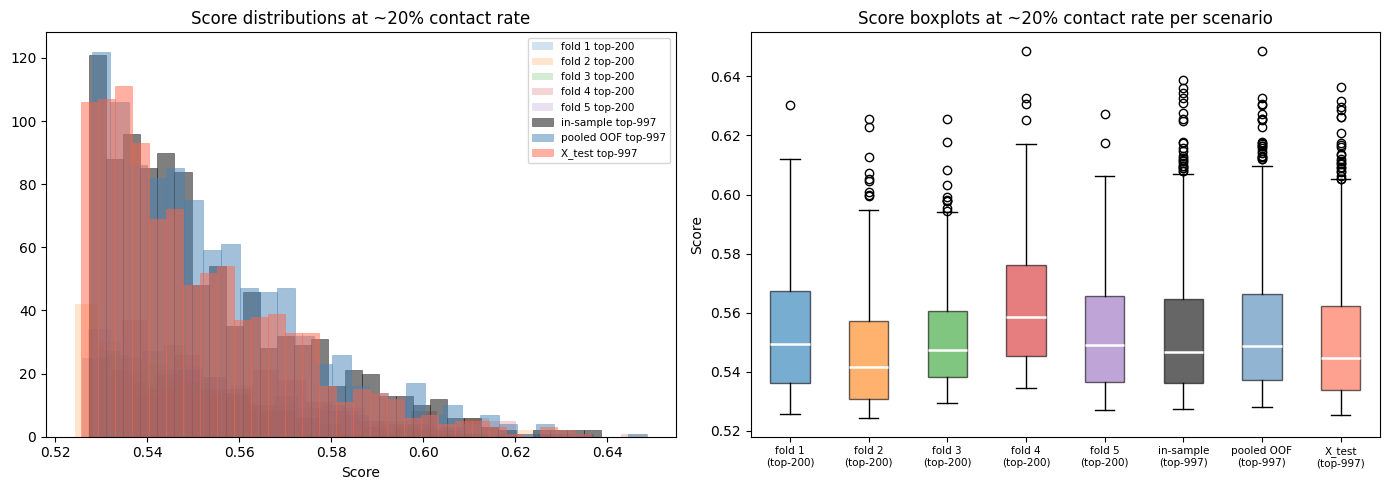

In [27]:
# ── score distribution: same 20% contact rate for all scenarios ───────────────
# in-sample / pooled OOF / X_test : top-k_oof  (997 / 5000 ≈ 20%)
# per-fold OOF                    : top-200     (200 / 1000 = 20%)
fold_colors = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fold_series = {
    fold: group.sort_values("score", ascending=False)["score"].values
    for fold, group in oof_config.groupby("outer_fold")
}

pooled_top = oof["score"].values[:k_oof]
test_top = test["score"].values[:k_oof]
train_top = train_df["score"].values[:k_oof]

# left: overlaid histograms
for i, (fold, scores) in enumerate(fold_series.items()):
    axes[0].hist(
        scores[:FOLD_MAX_TARGETS],
        bins=20,
        alpha=0.20,
        color=fold_colors[i],
        label=f"fold {fold} top-{FOLD_MAX_TARGETS}",
    )
axes[0].hist(
    train_top,
    bins=30,
    alpha=0.50,
    color="black",
    label=f"in-sample top-{k_oof}",
    edgecolor="black",
    linewidth=0.5,
)
axes[0].hist(
    pooled_top,
    bins=30,
    alpha=0.50,
    color="steelblue",
    label=f"pooled OOF top-{k_oof}",
    edgecolor="steelblue",
    linewidth=0.5,
)
axes[0].hist(
    test_top,
    bins=30,
    alpha=0.50,
    color="tomato",
    label=f"X_test top-{k_oof}",
    edgecolor="tomato",
    linewidth=0.5,
)
axes[0].set_title("Score distributions at ~20% contact rate")
axes[0].set_xlabel("Score")
axes[0].legend(fontsize=7.5)

# right: boxplots — each scenario at its own 20%-rate top-k
all_series = [scores[:FOLD_MAX_TARGETS] for scores in fold_series.values()]
all_series += [train_top, pooled_top, test_top]
labels = [f"fold {f}\n(top-{FOLD_MAX_TARGETS})" for f in fold_series]
labels += [f"in-sample\n(top-{k_oof})", f"pooled OOF\n(top-{k_oof})", f"X_test\n(top-{k_oof})"]
box_colors = [fold_colors[i] for i in range(len(fold_series))] + ["black", "steelblue", "tomato"]

bp = axes[1].boxplot(
    all_series, patch_artist=True, medianprops={"color": "white", "linewidth": 1.8}
)
for patch, color in zip(bp["boxes"], box_colors, strict=False):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_xticklabels(labels, fontsize=7.5)
axes[1].set_title("Score boxplots at ~20% contact rate per scenario")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

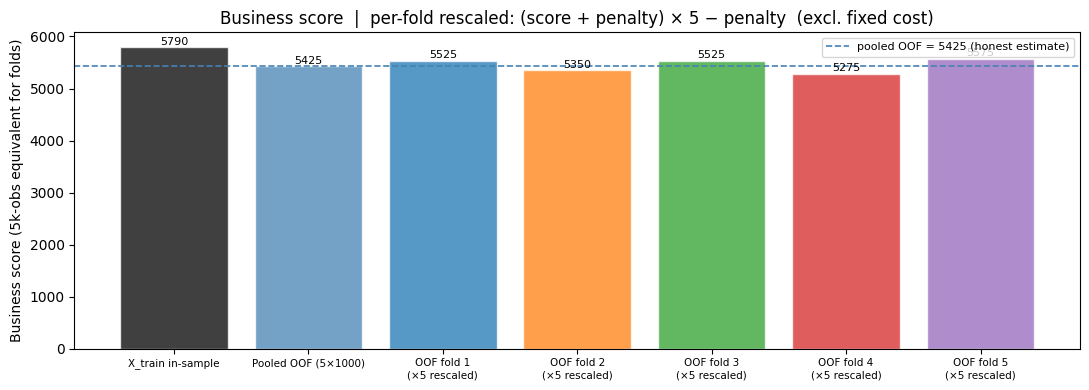

In [28]:
# ── business score bar chart ─────────────────────────────────────────────────
# Per-fold scores are rescaled to 5000-obs equivalent:
#   rescaled = (raw_fold_score + feature_penalty) * 5 - feature_penalty
# This removes the fixed penalty counted once, scales the classification signal
# by 5, then re-adds the penalty once — making fold scores comparable to pooled.
FEATURE_PENALTY = 200 * FEATURE_SIZE  # 1200

biz = scores_df[scores_df["business_score"].notna()].copy()
is_fold = biz["scenario"].str.startswith("OOF fold")
biz["business_score_plot"] = biz["business_score"].copy()
biz.loc[is_fold, "business_score_plot"] = (
    biz.loc[is_fold, "business_score"] + FEATURE_PENALTY
) * 5 - FEATURE_PENALTY
biz["label"] = biz.apply(
    lambda r: r["scenario"] + "\n(x5 rescaled)"
    if r["scenario"].startswith("OOF fold")
    else r["scenario"],
    axis=1,
)

bar_colors = ["black", "steelblue"] + [
    fold_colors[i] for i in range(len(oof_config["outer_fold"].unique()))
]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(
    biz["label"], biz["business_score_plot"], color=bar_colors, alpha=0.75, edgecolor="white"
)

pooled_val = biz.loc[biz["scenario"] == "Pooled OOF (5x1000)", "business_score_plot"].iloc[0]
ax.axhline(
    pooled_val,
    color="steelblue",
    linestyle="--",
    linewidth=1.2,
    label=f"pooled OOF = {pooled_val:.0f} (nested-CV estimate)",
)

for bar, val in zip(bars, biz["business_score_plot"], strict=False):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f"{val:.0f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.set_title(
    "Business score  |  per-fold rescaled: (score + penalty) x 5 - penalty  (excl. fixed cost)"
)
ax.set_ylabel("Business score (5k-obs equivalent for folds)")
ax.set_ylim(bottom=min(0, biz["business_score_plot"].min() * 0.95))
ax.tick_params(axis="x", labelsize=7.5)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Score threshold misclassification table

For each scenario with known labels (X_train in-sample, pooled OOF, per fold), divide selected observations into score bands and show — per band — how many FP (misclassified negatives) were selected. The goal is to see **at which score level the model makes the most errors** — i.e., where precision drops and FP concentrates.

In [29]:
N_BINS = 10  # number of score bands within top-k


def misclassification_table(y_true, scores, k, label, n_bins=N_BINS):
    """
    Split top-k selected observations into n_bins equal-size score bands
    (highest scores first = band 1). Returns a DataFrame with per-band stats.
    """
    y = np.asarray(y_true, dtype=int)
    s = np.asarray(scores, dtype=float)
    order = np.argsort(s)[::-1]
    top_y = y[order][:k]
    top_s = s[order][:k]

    rows = []
    band_size = max(1, k // n_bins)
    for i in range(n_bins):
        start = i * band_size
        end = min((i + 1) * band_size, k)
        if start >= k:
            break
        band_y = top_y[start:end]
        band_s = top_s[start:end]
        tp = int((band_y == 1).sum())
        fp = int((band_y == 0).sum())
        n = len(band_y)
        rows.append({
            "scenario": label,
            "band": i + 1,
            "rank_range": f"{start + 1}-{end}",
            "score_min": round(float(band_s.min()), 4),
            "score_max": round(float(band_s.max()), 4),
            "n": n,
            "tp": tp,
            "fp": fp,
            "precision": round(tp / n, 3),
            "fp_rate": round(fp / n, 3),
        })
    return pd.DataFrame(rows)


# ── contact rate used for ALL scenarios (rate-matched comparison) ──────────────
# pooled OOF:  k_oof / 5000 ≈ 19.94 %
# in-sample:   k_oof / 5000 ≈ 19.94 %
# per-fold:    200 / 1000   = 20.00 %  ← same rate, different pool size
K_FOLD_RATE = 0.20

tables = []

tables.append(
    misclassification_table(
        train_df["y_true"], train_df["score"], k=k_oof, label="X_train in-sample"
    )
)

tables.append(misclassification_table(oof["y_true"], oof["score"], k=k_oof, label="Pooled OOF"))

for fold, group in oof_config.groupby("outer_fold"):
    g = group.sort_values("score", ascending=False)
    # 20 % of fold size — rate-matched to pooled OOF and in-sample
    k_fold = round(K_FOLD_RATE * len(g))
    tables.append(
        misclassification_table(
            g["y_true"].values, g["score"].values, k=k_fold, label=f"OOF fold {fold}"
        )
    )

all_tables = pd.concat(tables, ignore_index=True)

k_per_fold = round(K_FOLD_RATE * 1000)
print(
    f"k used — in-sample: {k_oof}  pooled OOF: {k_oof}  per fold: {k_per_fold}  (all ~20% contact rate)"
)
print()

fp_pivot = all_tables.pivot_table(
    index=["band", "rank_range"],
    columns="scenario",
    values="fp",
    aggfunc="first",
)
prec_pivot = all_tables.pivot_table(
    index=["band", "rank_range"],
    columns="scenario",
    values="precision",
    aggfunc="first",
)

print("=== FP (false positives) per score band ===")
print(fp_pivot.to_string())
print()
print("=== Precision per score band ===")
print(prec_pivot.round(3).to_string())

k used — in-sample: 997  pooled OOF: 997  per fold: 200  (all ~20% contact rate)

=== FP (false positives) per score band ===
scenario         OOF fold 1  OOF fold 2  OOF fold 3  OOF fold 4  OOF fold 5  Pooled OOF  X_train in-sample
band rank_range                                                                                           
1    1–20               4.0         4.0         5.0        10.0         7.0         NaN                NaN
     1–99               NaN         NaN         NaN         NaN         NaN        28.0               11.0
2    100–198            NaN         NaN         NaN         NaN         NaN        14.0                7.0
     21–40              4.0         3.0         1.0         2.0         2.0         NaN                NaN
3    199–297            NaN         NaN         NaN         NaN         NaN        23.0               17.0
     41–60              6.0         2.0         5.0         4.0         1.0         NaN                NaN
4    298–396      

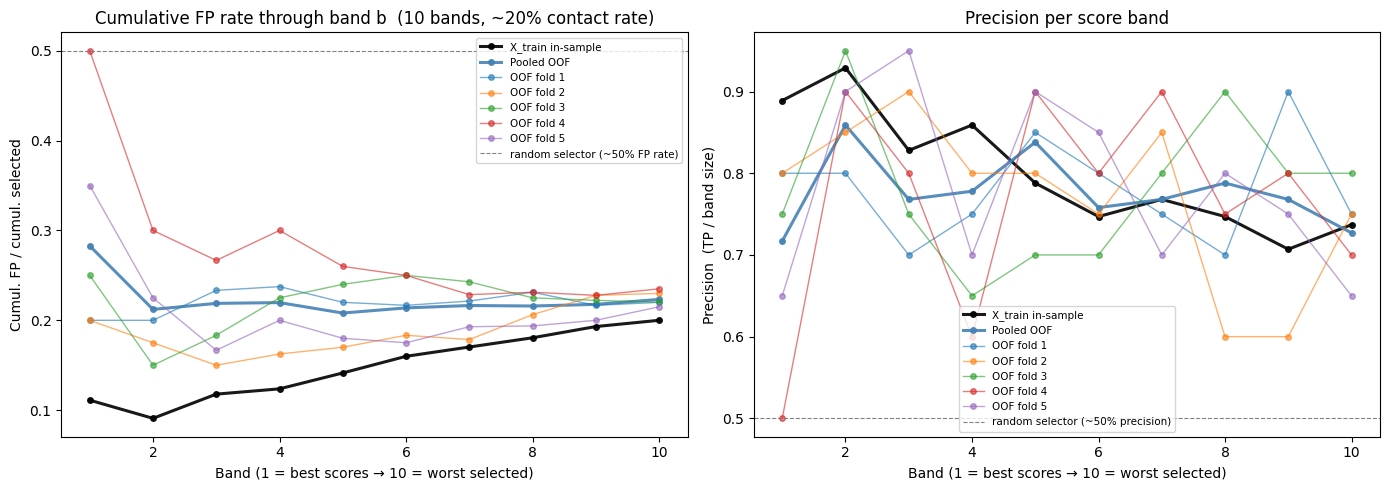

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scenarios_to_plot = ["X_train in-sample", "Pooled OOF"] + [
    f"OOF fold {f}" for f in sorted(oof_config["outer_fold"].unique())
]
plot_colors = {"X_train in-sample": "black", "Pooled OOF": "steelblue"}
for i, f in enumerate(sorted(oof_config["outer_fold"].unique())):
    plot_colors[f"OOF fold {f}"] = fold_colors[i]

for scenario in scenarios_to_plot:
    sub = all_tables[all_tables["scenario"] == scenario].sort_values("band")
    lw = 2.2 if scenario in ("X_train in-sample", "Pooled OOF") else 1.0
    alpha = 0.9 if scenario in ("X_train in-sample", "Pooled OOF") else 0.6

    # left: cumulative FP rate up through each band
    # = total FP in bands 1..b / total obs in bands 1..b
    cum_fp = sub["fp"].cumsum()
    cum_n = sub["n"].cumsum()
    cum_fp_rate = cum_fp / cum_n

    axes[0].plot(
        sub["band"],
        cum_fp_rate,
        marker="o",
        markersize=4,
        label=scenario,
        color=plot_colors[scenario],
        linewidth=lw,
        alpha=alpha,
    )

    # right: precision per band  (= 1 - local FP rate)
    axes[1].plot(
        sub["band"],
        sub["precision"],
        marker="o",
        markersize=4,
        label=scenario,
        color=plot_colors[scenario],
        linewidth=lw,
        alpha=alpha,
    )

# random baseline: ~50% negative rate in population
axes[0].axhline(
    0.5, color="gray", linestyle="--", linewidth=0.8, label="random selector (~50% FP rate)"
)
axes[0].set_title(f"Cumulative FP rate through band b  ({N_BINS} bands, ~20% contact rate)")
axes[0].set_xlabel("Band (1 = best scores → 10 = worst selected)")
axes[0].set_ylabel("Cumul. FP / cumul. selected")
axes[0].legend(fontsize=7.5)

axes[1].axhline(
    0.5, color="gray", linestyle="--", linewidth=0.8, label="random selector (~50% precision)"
)
axes[1].set_title("Precision per score band")
axes[1].set_xlabel("Band (1 = best scores → 10 = worst selected)")
axes[1].set_ylabel("Precision  (TP / band size)")
axes[1].legend(fontsize=7.5)

plt.tight_layout()
plt.show()